# pHash Duplicate Detection

Findet visuell identische Album-Cover **innerhalb eines Artists** per Perceptual Hash.

**Vorgehen:**
1. Alle Cover von Disk laden + Metadaten aus `albums_raw.csv` joinen
2. pHash für jedes Cover berechnen
3. Innerhalb jeder `artist_id`-Gruppe: Paare mit Hamming-Distanz ≤ `THRESHOLD` finden
4. Duplikate visuell inspizieren

**Scope:** Nur Within-Artist-Vergleich — kein Artist-übergreifender Vergleich (würde zufällig ähnliche Minimal-Cover fälschlicherweise matchen).

In [8]:
import sys
from pathlib import Path

import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from paths import COVERS_DIR, DATA_DIR

# Hamming-Distanz-Schwelle: 0–5 = visuell identisch
THRESHOLD = 5

print(f"Covers-Ordner: {COVERS_DIR}")
print(f"Threshold:     Hamming ≤ {THRESHOLD}")

Covers-Ordner: /Users/tjarek/uni/album-genre-classifier/data/covers
Threshold:     Hamming ≤ 5


## 1. Cover von Disk laden + Metadaten joinen

In [9]:
# Disk ist Ground Truth — was liegt, existiert
rows = []
for jpg in sorted(COVERS_DIR.rglob("*.jpg")):
    # Dateiname: {artist_name}_{album_id}.jpg → album_id = letzter _-separierter Teil
    album_id = jpg.stem.rsplit("_", 1)[-1]
    rows.append({
        "genre": jpg.parent.name,
        "album_id": album_id,
        "cover_path": jpg,
    })

disk_df = pd.DataFrame(rows)

# Metadaten aus albums_raw.csv joinen
raw = pd.read_csv(DATA_DIR / "albums_raw.csv")
raw = raw.drop_duplicates(subset="album_id", keep="first")

df = disk_df.merge(
    raw[["album_id", "album_name", "release_date", "artist_id", "artist_name"]],
    on="album_id",
    how="left",
)

missing = df["artist_id"].isna().sum()
print(f"Cover auf Disk:         {len(df)}")
print(f"Ohne Metadaten-Match:   {missing}")
print()
print(df.groupby("genre").size().sort_values(ascending=False).to_string())

Cover auf Disk:         2559
Ohne Metadaten-Match:   0

genre
techno              300
house               277
metal               275
jazz                272
indie_rock          265
alternative_rock    253
reggae              249
hiphop              236
country             224
classical           208


## 2. pHash für alle Cover berechnen

~1–2 Minuten für ~2600 Cover.

In [10]:
hashes = []
for path in tqdm(df["cover_path"], desc="pHash berechnen"):
    with Image.open(path) as img:
        hashes.append(imagehash.phash(img))

df["phash"] = hashes
print("Fertig.")

pHash berechnen: 100%|██████████| 2559/2559 [00:04<00:00, 541.58it/s]

Fertig.


## 3. Duplikat-Cluster finden (Connected Components)

Statt paarweisem Vergleich werden **Cluster** gebildet: alle Cover eines Artists, die transitiv zusammenhängen, landen in einer Gruppe. Behalten wird das älteste Release im Cluster — alle anderen werden gelöscht.

```
Beispiel:  A ↔ B ↔ C  →  Cluster {A, B, C}  →  behalte A, lösche B + C
```

In [11]:
from collections import defaultdict, deque

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

clusters = []  # [{artist_name, genre, keep: row-dict, dupes: [row-dicts]}]

for artist_id, group in df.groupby("artist_id", sort=False):
    # Ältestes Release zuerst (Tie-Breaker: NaT ans Ende)
    group = group.sort_values("release_date", na_position="last").reset_index(drop=True)
    n = len(group)

    # Adjazenzliste aufbauen
    adj: dict[int, set[int]] = defaultdict(set)
    for i in range(n):
        for j in range(i + 1, n):
            if group.loc[i, "phash"] - group.loc[j, "phash"] <= THRESHOLD:
                adj[i].add(j)
                adj[j].add(i)

    # Connected Components per BFS
    visited: set[int] = set()
    for start in range(n):
        if start in visited:
            continue
        if not adj[start]:          # isolierter Knoten — kein Duplikat
            visited.add(start)
            continue
        component: list[int] = []
        queue: deque[int] = deque([start])
        while queue:
            node = queue.popleft()
            if node in visited:
                continue
            visited.add(node)
            component.append(node)
            queue.extend(adj[node] - visited)

        if len(component) > 1:
            # Gruppe ist bereits nach Datum sortiert → kleinster Index = ältestes Release
            component.sort()
            keep_idx, *dupe_idxs = component
            clusters.append({
                "artist_name": group.loc[keep_idx, "artist_name"],
                "genre":       group.loc[keep_idx, "genre"],
                "keep":        group.loc[keep_idx].to_dict(),
                "dupes":       [group.loc[j].to_dict() for j in dupe_idxs],
            })

total_dupes = sum(len(c["dupes"]) for c in clusters)
print(f"Cluster gefunden:    {len(clusters)}")
print(f"Zu löschende Cover:  {total_dupes}")

Cluster gefunden:    9
Zu löschende Cover:  10


## 4. Übersicht pro Genre

In [12]:
if not clusters:
    print("Keine Duplikate gefunden.")
else:
    genre_counts = defaultdict(int)
    for c in clusters:
        genre_counts[c["genre"]] += len(c["dupes"])

    print("Zu löschende Cover pro Genre:")
    for genre, count in sorted(genre_counts.items(), key=lambda x: -x[1]):
        print(f"  {genre:<20s} {count}")
    print()
    print("Cluster-Beispiele (Artist | behalten | löschen):")
    for c in clusters[:10]:
        keep_name = c["keep"]["album_name"] or "?"
        dupe_names = ", ".join(d["album_name"] or "?" for d in c["dupes"])
        print(f"  {c['artist_name']:<25s}  ✓ {keep_name[:30]:<32s}  ✗ {dupe_names[:50]}")

Zu löschende Cover pro Genre:
  house                3
  country              2
  indie_rock           2
  hiphop               1
  jazz                 1
  techno               1

Cluster-Beispiele (Artist | behalten | löschen):
  Johnny Cash                ✓ My Way                            ✗ My Way Volume II
  Shania Twain               ✓ Up!                               ✗ Up! (Red and Green Versions)
  The Notorious B.I.G.       ✓ Ready to Die (The Remaster)       ✗ Ready to Die (The Remaster)
  Kerri Chandler             ✓ Spaces and Places Album Sample    ✗ Spaces and Places Album Sampler 3, Spaces and Plac
  Larry Heard                ✓ Dance 2000, Part 1                ✗ Dance 2000, Part 2
  Grizzly Bear               ✓ Veckatimest                       ✗ Veckatimest (Deluxe Version)
  Interpol                   ✓ Antics (The Special Edition)      ✗ Antics
  Louis Armstrong            ✓ Vaults                            ✗ Vaults Volume II
  Pan-Pot                    ✓ The Ot

## 5. Visuelle Inspektion

Pro Cluster: **links** das zu behaltende Cover, **rechts** die Duplikate. Cluster mit mehr als einem Duplikat werden vollständig angezeigt.

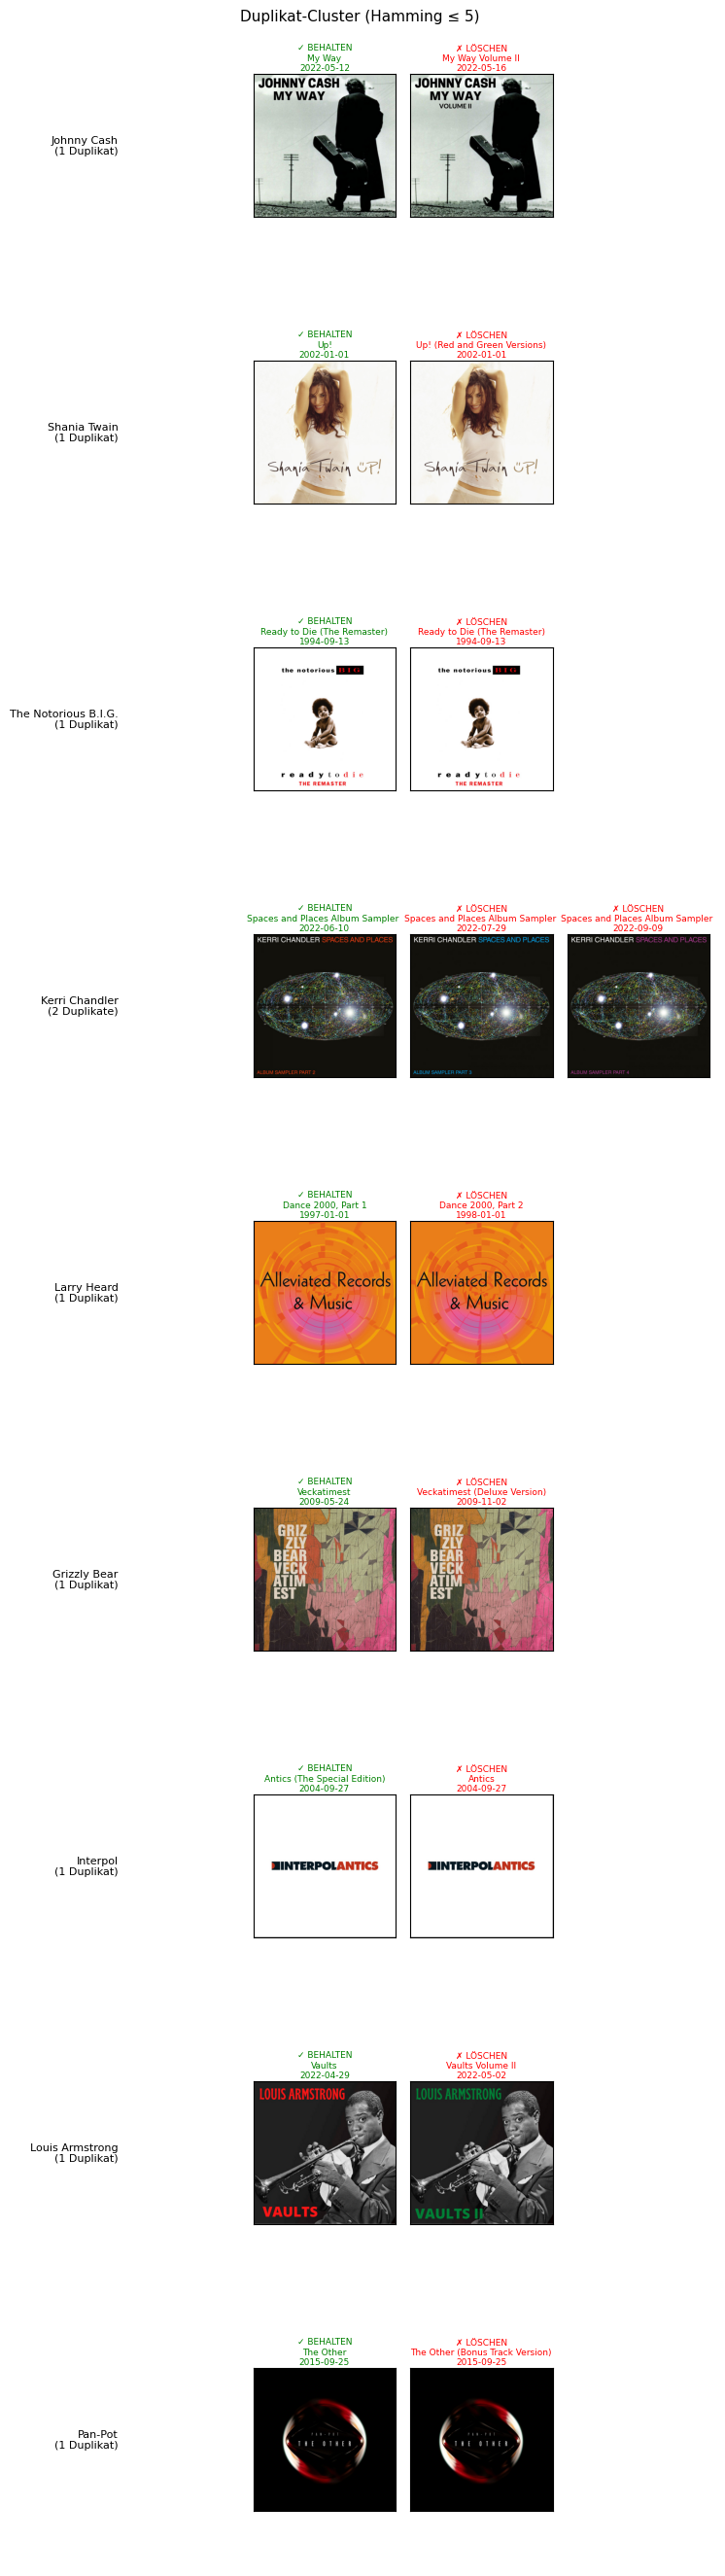

In [13]:
N_SHOW = 12  # Anzahl Cluster anzeigen

if not clusters:
    print("Keine Duplikate zum Anzeigen.")
else:
    sample = clusters[:N_SHOW]
    # Breite = 1 (keep) + max(dupes) über alle angezeigten Cluster
    max_cols = max(1 + len(c["dupes"]) for c in sample)

    fig, axes = plt.subplots(
        len(sample), max_cols,
        figsize=(max_cols * 2.5, len(sample) * 3),
        squeeze=False,
    )

    for row_idx, c in enumerate(sample):
        entries = [c["keep"]] + c["dupes"]
        for col_idx in range(max_cols):
            ax = axes[row_idx, col_idx]
            if col_idx < len(entries):
                entry = entries[col_idx]
                ax.imshow(Image.open(entry["cover_path"]))
                date_str = str(entry["release_date"])[:10] if pd.notna(entry["release_date"]) else "?"
                label = "✓ BEHALTEN" if col_idx == 0 else "✗ LÖSCHEN"
                ax.set_title(
                    f"{label}\n{str(entry['album_name'] or '')[:32]}\n{date_str}",
                    fontsize=6.5, pad=3,
                    color="green" if col_idx == 0 else "red",
                )
            else:
                ax.axis("off")  # leere Zelle für kürzere Cluster
            ax.set_xticks([])
            ax.set_yticks([])

        axes[row_idx, 0].set_ylabel(
            f"{c['artist_name']}\n({len(c['dupes'])} Duplikat{'e' if len(c['dupes']) > 1 else ''})",
            fontsize=8, rotation=0, labelpad=100, va="center", ha="right",
        )

    plt.suptitle(f"Duplikat-Cluster (Hamming ≤ {THRESHOLD})", fontsize=11)
    plt.tight_layout()
    plt.show()

## 6. Duplikate von Disk löschen

**Nur ausführen wenn die visuelle Inspektion oben plausibel aussieht.**

Behalten wird jeweils das **älteste Release** pro Cluster. Dank Connected Components gibt es keine Konflikte mehr.

In [14]:
if not clusters:
    print("Nichts zu löschen.")
else:
    to_delete = [
        Path(d["cover_path"])
        for c in clusters
        for d in c["dupes"]
    ]

    deleted = 0
    missing = 0
    for path in to_delete:
        if path.exists():
            path.unlink()
            deleted += 1
        else:
            missing += 1

    print(f"Gelöscht:            {deleted} Dateien")
    if missing:
        print(f"Bereits fehlend:     {missing} (übersprungen)")
    print()

    genre_counts = {}
    for genre_dir in sorted(COVERS_DIR.iterdir()):
        if genre_dir.is_dir():
            genre_counts[genre_dir.name] = len(list(genre_dir.glob("*.jpg")))
    print("Cover pro Genre nach Bereinigung:")
    for genre, count in sorted(genre_counts.items(), key=lambda x: -x[1]):
        print(f"  {genre:<20s} {count}")
    print(f"  {'GESAMT':<20s} {sum(genre_counts.values())}")

Gelöscht:            10 Dateien

Cover pro Genre nach Bereinigung:
  techno               299
  metal                275
  house                274
  jazz                 271
  indie_rock           263
  alternative_rock     253
  reggae               249
  hiphop               235
  country              222
  classical            208
  GESAMT               2549
